In [ ]:
from qiskit_nature.second_q.hamiltonians.lattices import SquareLattice,line_lattice,BoundaryCondition,LineLattice
from qiskit_nature.second_q.hamiltonians import FermiHubbardModel
from qiskit_nature.second_q.mappers import  JordanWignerMapper

line_lattice = LineLattice(num_nodes=4, boundary_condition=BoundaryCondition.OPEN)
fermi_hubbard_model = FermiHubbardModel(
    line_lattice.uniform_parameters(
        uniform_interaction=-1.0,
        uniform_onsite_potential=0.0,
    ),
    onsite_interaction=0.1,
)

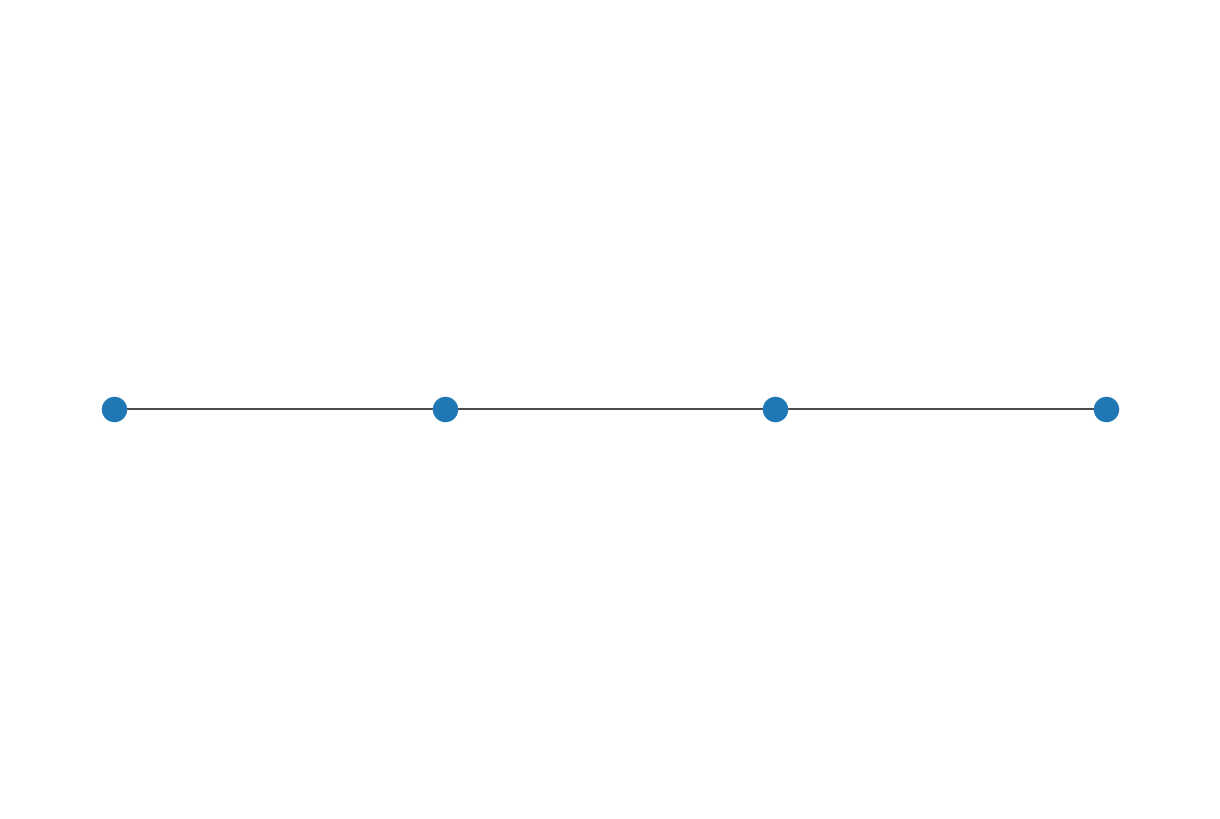

In [63]:
line_lattice.draw()

In [52]:
fermi_op = JordanWignerMapper().map(fermi_hubbard_model.second_q_op())
fermi_op

SparsePauliOp(['IIIIIYZY', 'IIIIIXZX', 'IIIYZYII', 'IIIXZXII', 'IYZYIIII', 'IXZXIIII', 'IIIIYZYI', 'IIIIXZXI', 'IIYZYIII', 'IIXZXIII', 'YZYIIIII', 'XZXIIIII', 'IIIIIIII', 'IIIIIIZI', 'IIIIIIIZ', 'IIIIIIZZ', 'IIIIZIII', 'IIIIIZII', 'IIIIZZII', 'IIZIIIII', 'IIIZIIII', 'IIZZIIII', 'ZIIIIIII', 'IZIIIIII', 'ZZIIIIII'],
              coeffs=[-0.5  +0.j, -0.5  +0.j, -0.5  +0.j, -0.5  +0.j, -0.5  +0.j, -0.5  +0.j,
 -0.5  +0.j, -0.5  +0.j, -0.5  +0.j, -0.5  +0.j, -0.5  +0.j, -0.5  +0.j,
  0.1  +0.j, -0.025+0.j, -0.025+0.j,  0.025+0.j, -0.025+0.j, -0.025+0.j,
  0.025+0.j, -0.025+0.j, -0.025+0.j,  0.025+0.j, -0.025+0.j, -0.025+0.j,
  0.025+0.j])

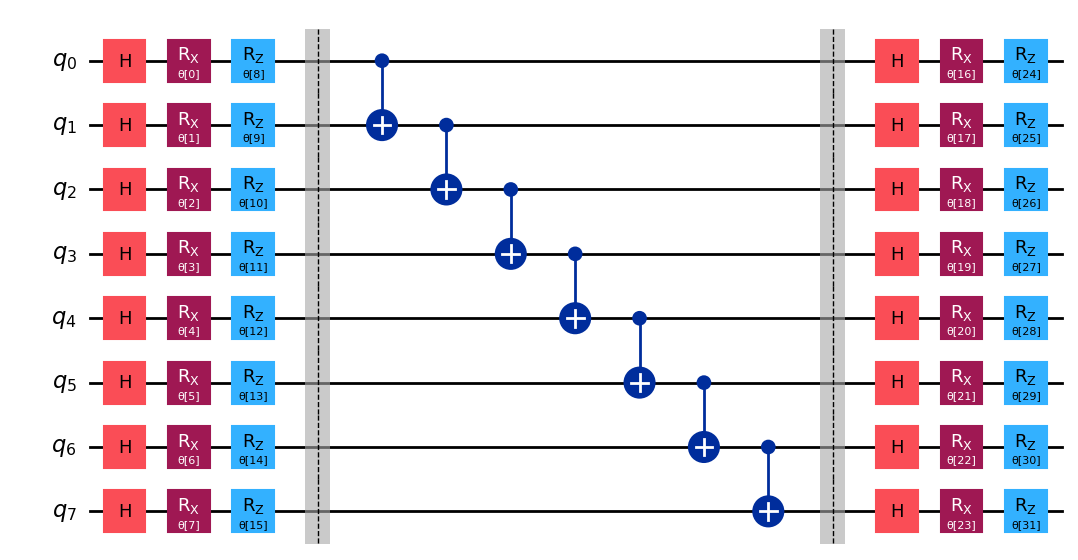

In [ ]:
from qiskit.circuit.library import TwoLocal

tl_circuit = TwoLocal(num_qubits=8,
    rotation_blocks=["h", "rx","rz"],
    entanglement_blocks="cx",
    entanglement="linear",
    reps=1,
    insert_barriers=True,
    parameter_prefix="θ",
)
tl_circuit.decompose().draw('mpl')

In [60]:
from qiskit.primitives import Estimator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA, L_BFGS_B, SLSQP
from qiskit_algorithms.utils import algorithm_globals
import numpy as np

# we will iterate over these different optimizers
#optimizers = [COBYLA(maxiter=80), L_BFGS_B(maxiter=60), SLSQP(maxiter=60)]

estimator = Estimator()
ansatz = TwoLocal(num_qubits=8,
    rotation_blocks=["h", "rx","rz"],
    entanglement_blocks="cx",
    entanglement="linear",
    reps=4,
    insert_barriers=True,
    parameter_prefix="y",
)
counts =[]
values = []
optimizer = SLSQP()
def store_intermediate_result(eval_count, parameters, mean, std):
    counts.append(eval_count)
    values.append(mean)

vqe = VQE(estimator, ansatz, optimizer, callback=store_intermediate_result)
result = vqe.compute_minimum_eigenvalue(operator=fermi_op)
    # converge_counts[i] = np.asarray(counts)
    # converge_vals[i] = np.asarray(values)


/var/folders/8x/k_m4pmb11437ktb_r6tjzt2c0000gn/T/ipykernel_56884/351769608.py:10: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator()


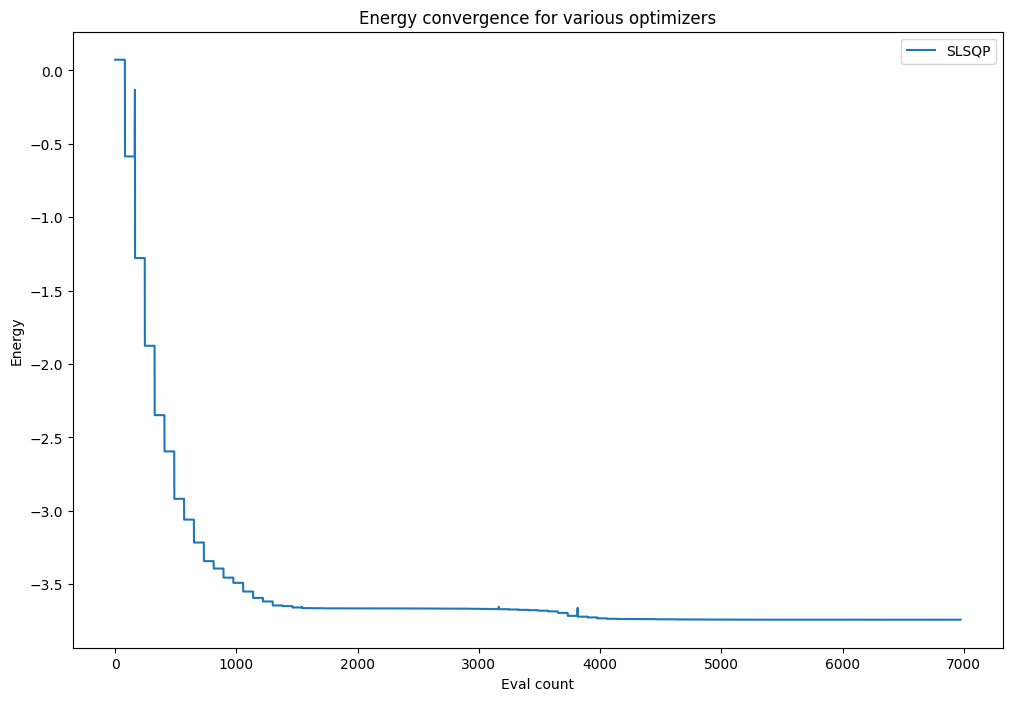

In [61]:
import pylab

pylab.rcParams["figure.figsize"] = (12, 8)
pylab.plot(counts, values, label=type(optimizer).__name__)
pylab.xlabel("Eval count")
pylab.ylabel("Energy")
pylab.title("Energy convergence for various optimizers")
pylab.legend(loc="upper right");